In [4]:
# ===============================
import os
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Patch
from scipy.stats import pearsonr, spearmanr, kruskal
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
from sklearn.metrics import r2_score, mean_absolute_error
from lifelines.utils import concordance_index
from dynamicTreeCut import cutreeHybrid
from statannotations.Annotator import Annotator

# Plotting Aesthetics
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'DejaVu Sans'
sns.set(style="white", context="talk", font_scale=1.1)

In [5]:

# USER CONFIGURATION
# Update this path to your specific Dabrafenib model file
model_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/optuna_models/DABRAFENIB_BRAF_forgeModel_optuna100.pkl" 


In [6]:
# %%
# ===============================
# 1. Data Loading & Processing
# ===============================
print(f"Loading model: {model_path}")
with open(model_path, "rb") as f:
    model = pickle.load(f)

# Load raw matrices
exp_data = pd.read_csv(model.exp_path, header=0, index_col=0)
dep_data = pd.read_csv(model.dep_path, header=0, index_col=0)
ic50_data = getattr(model, 'ic50_data', pd.read_csv(model.ic50_path, header=0, index_col=0).T)
if ic50_data.shape[0] < ic50_data.shape[1]: ic50_data = ic50_data.T # Ensure (Cells x Drugs)

# Intersect Cell Lines
common = list(set(exp_data.index) & set(dep_data.index) & set(ic50_data.index))
train_cells = list(set(model.train_cellLines) & set(common))
test_cells = list(set(model.test_cellLines) & set(common))

# Filter & Align Data
model.exp_data = exp_data.loc[common, model.hcg_list]
model.dep_data = dep_data.loc[common, model.target]
model.ic50_data = ic50_data.loc[common, model.drug]

# Prepare Matrices
G_train = model.exp_data.loc[train_cells].to_numpy()
G_test  = model.exp_data.loc[test_cells].to_numpy()
D_train = model.dep_data.loc[train_cells].to_numpy().reshape(-1, 1)
D_test  = model.dep_data.loc[test_cells].to_numpy().reshape(-1, 1)
I_train = model.ic50_data.loc[train_cells].to_numpy().reshape(-1, 1)
I_test  = model.ic50_data.loc[test_cells].to_numpy().reshape(-1, 1)

# Latent Factors & Predictions
Z_train = G_train @ model.W
Z_test  = G_test  @ model.W
pred_D_train, pred_I_train = Z_train @ model.hD, Z_train @ model.hI
pred_D_test,  pred_I_test  = Z_test  @ model.hD, Z_test  @ model.hI

print(f"Processed: {len(train_cells)} Train, {len(test_cells)} Test cell lines.")

Loading model: /home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/optuna_models/DABRAFENIB_BRAF_forgeModel_optuna100.pkl
Processed: 474 Train, 118 Test cell lines.


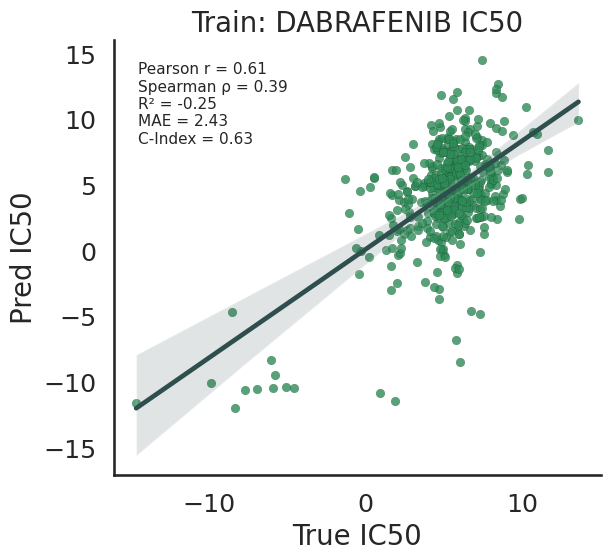

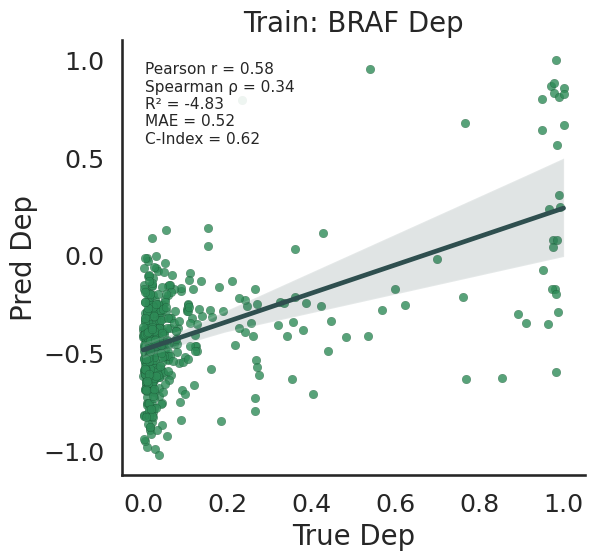

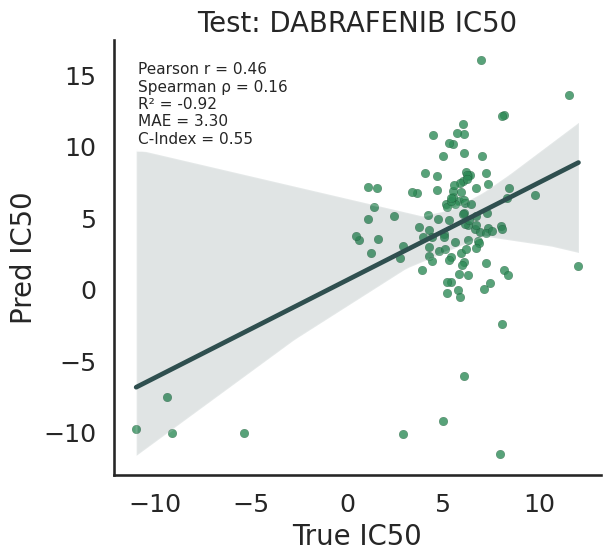

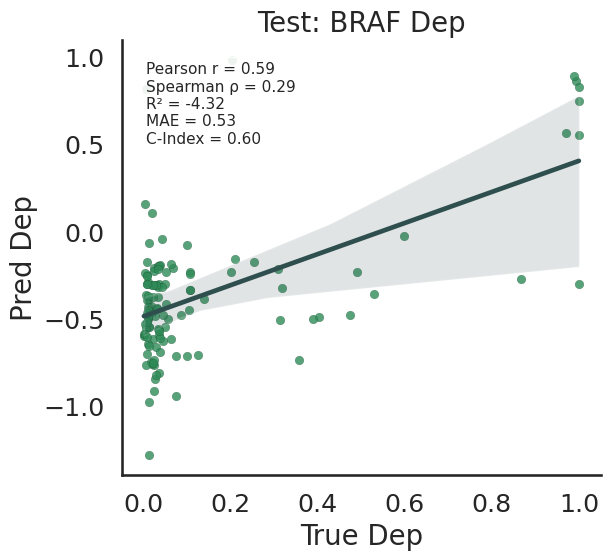

In [7]:


# %%
# ===============================
# 2. Scatter Plots (Regression)
# ===============================
def plot_regression(x, y, title, xlabel, ylabel, filename):
    x, y = x.flatten(), y.flatten()
    fig, ax = plt.subplots(figsize=(6.5, 6))
    sns.regplot(x=x, y=y, ax=ax, color='darkslategrey', scatter_kws={'s': 40, 'color': 'seagreen', 'edgecolors': 'black', 'linewidths': 0.1}, line_kws={'color': 'darkslategrey'}, ci=100)
    
    # Metrics
    metrics = (f"Pearson r = {pearsonr(x, y)[0]:.2f}\nSpearman ρ = {spearmanr(x, y)[0]:.2f}\n"
               f"R² = {r2_score(x, y):.2f}\nMAE = {mean_absolute_error(x, y):.2f}\nC-Index = {concordance_index(x, y):.2f}")
    ax.text(0.05, 0.95, metrics, transform=ax.transAxes, fontsize=11, va="top", bbox=dict(boxstyle="round", fc="white", alpha=0.9))
    
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    sns.despine()
    plt.tight_layout()
    plt.savefig(f"/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/{filename}", dpi=300, bbox_inches="tight")
    plt.show()

plot_regression(I_train, pred_I_train, f"Train: {model.drug} IC50", "True IC50", "Pred IC50", "Dabrafenib_scatter_ic50_train.pdf")
plot_regression(D_train, pred_D_train, f"Train: {model.target} Dep", "True Dep", "Pred Dep", "Dabrafenib_scatter_dep_train.pdf")
plot_regression(I_test, pred_I_test, f"Test: {model.drug} IC50", "True IC50", "Pred IC50", "Dabrafenib_scatter_ic50_test.pdf")
plot_regression(D_test, pred_D_test, f"Test: {model.target} Dep", "True Dep", "Pred Dep", "Dabrafenib_scatter_dep_test.pdf")

In [9]:
# Combine train + test
cell_lines = train_cells + test_cells
sets = ["train"] * len(train_cells) + ["test"] * len(test_cells)
# Flatten all arrays
actual_dep = np.concatenate([D_train.flatten(), D_test.flatten()])
pred_dep = np.concatenate([pred_D_train.flatten(), pred_D_test.flatten()])
actual_ic50 = np.concatenate([I_train.flatten(), I_test.flatten()])
pred_ic50 = np.concatenate([pred_I_train.flatten(), pred_I_test.flatten()])
# Build DataFrame
df_scatter = pd.DataFrame({
    "Cell_line": cell_lines,
    "Set": sets,
    "Actual_Dep": actual_dep,
    "Predicted_Dep": pred_dep,
    "Actual_Ic50": actual_ic50,
    "Predicted_Ic50": pred_ic50
})
# Save
output_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/revision_final/Suppl_data/Dabrafenib_model_data.csv"
df_scatter.to_csv(output_path, index=False)
print(f"Saved {len(df_scatter)} rows to {output_path}")
df_scatter.head()

Saved 592 rows to /home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/revision_final/Suppl_data/Dabrafenib_model_data.csv


,Cell_line,Set,Actual_Dep,Predicted_Dep,Actual_Ic50,Predicted_Ic50
0,NH12,train,0.026877,-0.459969,4.62127,2.461932
1,K562,train,0.271199,-0.251219,4.96157,-0.316465
2,SKES1,train,0.016586,-0.876913,8.32811,12.004279
3,MDAMB231,train,0.211430,-0.133317,4.96509,2.389911
4,NCIH2087,train,0.534125,-0.414838,3.54155,3.690757


..cutHeight not given, setting it to 2501.0474497128052  ===>  99% of the (truncated) height range in dendro.
..done.


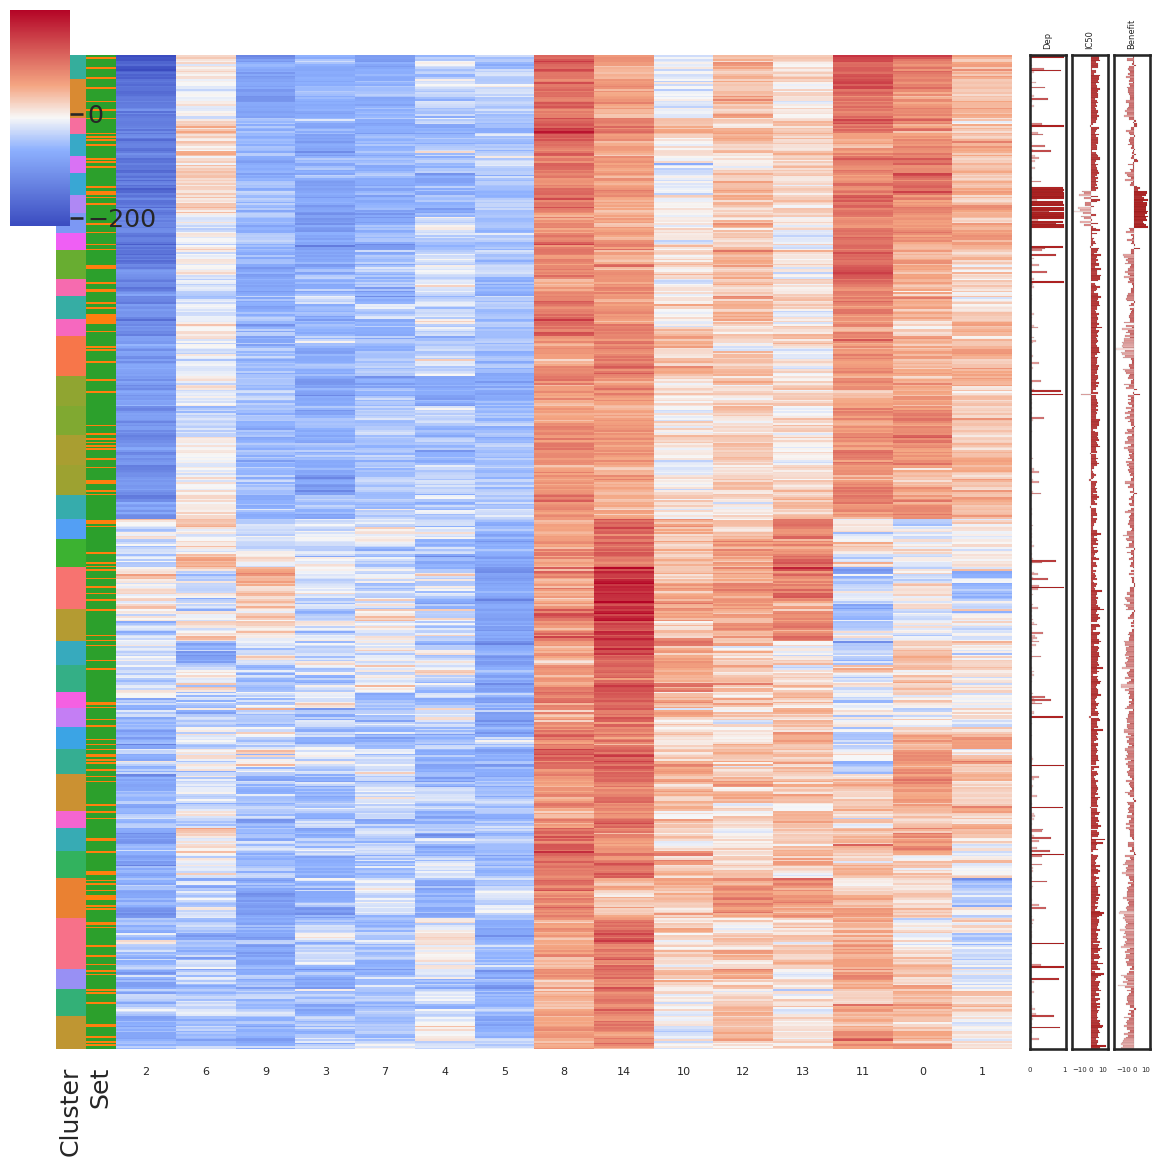

In [ ]:
# %%
# ===============================
# 3. Heatmap (Latent Factors)
# ===============================
# Prepare plotting DF
df_all = pd.DataFrame(np.vstack([Z_train, Z_test]), index=train_cells + test_cells)
df_all["Set"] = ["Train"]*len(train_cells) + ["Test"]*len(test_cells)
df_all["True_Dep"] = model.dep_data.loc[df_all.index]
df_all["True_IC50"] = model.ic50_data.loc[df_all.index]
df_all["Benefit"] = (np.vstack([pred_D_train, pred_D_test]) - np.vstack([pred_I_train, pred_I_test])).flatten()
Z_only = df_all.iloc[:, :Z_train.shape[1]]

# Clustering
row_link = linkage(pdist(Z_only), method='ward')
col_link = linkage(pdist(Z_only.T), method='ward')
clusters = cutreeHybrid(row_link, pdist(Z_only), deepSplit=4, minClusterSize=10)['labels']

# Colors
clust_pal = sns.color_palette("husl", len(np.unique(clusters[clusters!=0])))
clust_lut = {**{0:'lightgrey'}, **dict(zip(sorted(np.unique(clusters[clusters!=0])), clust_pal))}
row_colors = pd.DataFrame({"Cluster": pd.Series(clusters, index=df_all.index).map(clust_lut),
                           "Set": df_all["Set"].map({"Train": "#2ca02c", "Test": "#ff7f0e"})})
deep_blue   = '#3B4CC0'   # strong blue
soft_blue   = '#8DB0FE'   # light blue
neutral     = '#F7F7F7'   # keep neutral
soft_orange = '#F4A582'   # light orange
deep_orange = '#B40426'   # strong orange
green_pink_cmap = LinearSegmentedColormap.from_list('green_pink_cmap', [(
    0.0, deep_blue), (0.35, soft_blue), (0.5, neutral), (0.65, soft_orange), (1.0, deep_orange)], N=256)
muted_reds = LinearSegmentedColormap.from_list(
    "muted_reds", ["mistyrose", "indianred", "firebrick"])
benefit_cmap = sns.diverging_palette(
    240, 10, as_cmap=True)  # Blue to Red for benefit score
cmap_reds = LinearSegmentedColormap.from_list("reds", ["mistyrose", "indianred", "firebrick"])

# Plot
cg = sns.clustermap(Z_only, row_linkage=row_link, col_linkage=col_link, row_colors=row_colors, 
                    cmap=green_pink_cmap, figsize=(12, 12), dendrogram_ratio=(0.04, 0.03), linewidths=0)
cg.ax_heatmap.set_yticks([]); cg.ax_col_dendrogram.set_visible(False)
cg.ax_heatmap.tick_params(axis='x', labelsize=8)


# Side Bars
ordered_idx = Z_only.index[cg.dendrogram_row.reordered_ind]
pos = cg.ax_heatmap.get_position()

def add_sidebar(vals, title, x_off, cmap_bar, vmin=None, vmax=None):
    ax = cg.fig.add_axes([pos.x1 + x_off, pos.y0, 0.03, pos.height])
    vmin, vmax = (vals.min(), vals.max()) if vmin is None else (vmin, vmax)
    colors = cmap_bar(Normalize(vmin, vmax)(vals))
    ax.barh(np.arange(len(vals)), vals, height=1, color=colors, edgecolor='black', linewidth=0.05)
    ax.set_ylim(0, len(vals)); ax.set_yticks([]);  ax.tick_params(axis='x', labelsize=5); ax.set_title(title, fontsize=6, rotation=90)
    return ax

add_sidebar(df_all.loc[ordered_idx, "True_Dep"], "Dep", 0.015, cmap_reds, 0, 1)
add_sidebar(df_all.loc[ordered_idx, "True_IC50"], "IC50", 0.05, cmap_reds)
add_sidebar(df_all.loc[ordered_idx, "Benefit"], "Benefit", 0.085, cmap_reds)

# Legends
cg.ax_row_dendrogram.set_visible(False) 
plt.savefig(os.path.join("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Code/Suppl_figs", "Dabrafenib_heatmap_latent_factors.pdf"), dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
df_test_plot.to_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/revision_final/Suppl_data/Dabrafenib_boxplot.csv", index=False)

Loading model from: /home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/optuna_models/DABRAFENIB_BRAF_forgeModel_optuna100.pkl
Loading Expression, Dependency, and IC50 data...
Common cell lines found: 700
Final Data Shapes -> Exp: (696, 201), Dep: (696,), IC50: (696,)


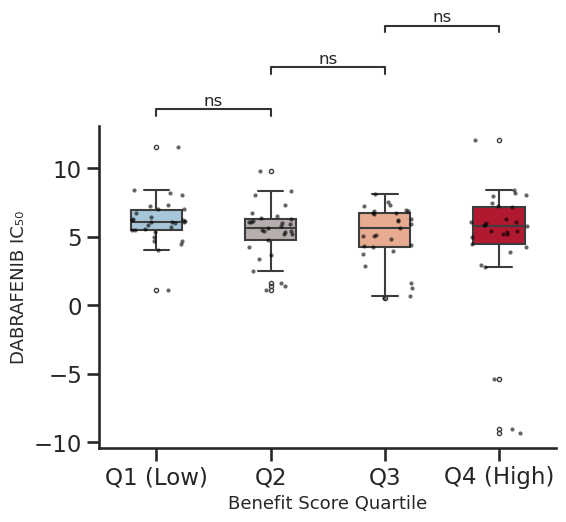

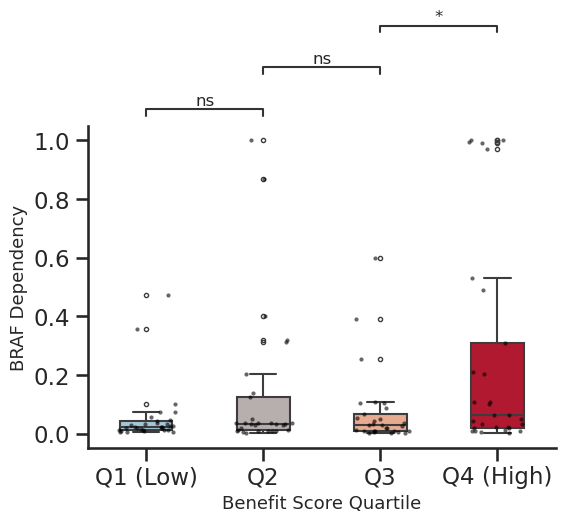

Processing complete. Plots saved.


In [ ]:
# ===============================
# 0. Imports & plotting setup
# ===============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pickle
import os
from scipy.stats import kruskal
from statannotations.Annotator import Annotator
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'DejaVu Sans'
# ===============================
# 1. Load the Model
# ===============================
model_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/optuna_models/DABRAFENIB_BRAF_forgeModel_optuna100.pkl"
print(f"Loading model from: {model_path}")
with open(model_path, "rb") as f:
    model = pickle.load(f)
# ===============================
# 2. Data Preparation & Alignment
# ===============================
print("Loading Expression, Dependency, and IC50 data...")
exp_data = pd.read_csv(model.exp_path, header=0, index_col=0)
dep_data = pd.read_csv(model.dep_path, header=0, index_col=0)
ic50_data = pd.read_csv(model.ic50_path, header=0, index_col=0).T
common_cellLines = list(set(exp_data.index) & set(dep_data.index) & set(ic50_data.index))
print(f"Common cell lines found: {len(common_cellLines)}")
# Filter for target gene and drug
exp_data_subset = exp_data.loc[common_cellLines, model.hcg_list].drop_duplicates(keep='first')
dep_target = dep_data.loc[common_cellLines, model.target].dropna().drop_duplicates(keep='first')
drug_ic50 = ic50_data.loc[common_cellLines, model.drug].dropna().drop_duplicates(keep='first')
# Re-align to dependency index
exp_data_subset = exp_data.loc[dep_target.index, model.hcg_list]
drug_ic50 = ic50_data.loc[dep_target.index, model.drug]
print(f"Final Data Shapes -> Exp: {exp_data_subset.shape}, Dep: {dep_target.shape}, IC50: {drug_ic50.shape}")
# ===============================
# 3. Train / Test Splitting
# ===============================
common_train_cellLines = list(set(model.train_cellLines) & set(exp_data_subset.index))
common_test_cellLines = list(set(model.test_cellLines) & set(exp_data_subset.index))
G_train = exp_data_subset.loc[common_train_cellLines, :].to_numpy()
G_test  = exp_data_subset.loc[common_test_cellLines, :].to_numpy()
D_train = dep_target.loc[common_train_cellLines].to_numpy().reshape(-1, 1)
D_test  = dep_target.loc[common_test_cellLines].to_numpy().reshape(-1, 1)
I_train = drug_ic50.loc[common_train_cellLines].to_numpy().reshape(-1, 1)
I_test  = drug_ic50.loc[common_test_cellLines].to_numpy().reshape(-1, 1)
# ===============================
# 4. Latent Factor Calculations & Predictions
# ===============================
Z_train = G_train @ model.W
Z_test  = G_test  @ model.W
pred_D_train = Z_train @ model.hD
pred_D_test  = Z_test  @ model.hD
pred_I_train = Z_train @ model.hI
pred_I_test  = Z_test  @ model.hI
# Benefit Score = Predicted Dependency - Predicted IC50
benefit_train = pred_D_train - pred_I_train
benefit_test  = pred_D_test - pred_I_test
# ===============================
# 5. Build DataFrame for Plotting (Test Set)
# ===============================
df_test_plot = pd.DataFrame({
    "IC50": I_test.flatten(),
    f"{model.target} Dependency": D_test.flatten(),
    "Benefit Score": benefit_test.flatten()
})
df_test_plot["Benefit Score Bin"] = pd.qcut(
    df_test_plot["Benefit Score"],
    q=4,
    labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)
# ===============================
# 6. Visualization & Statistics
# ===============================
save_path = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs"
os.makedirs(save_path, exist_ok=True)
sns.set(style="white", context="talk")
palette = ['#9ecae1', "#b8adad", '#f4a582', '#ca0020']
box_width = 0.45
pairs = [("Q1 (Low)", "Q2"), ("Q2", "Q3"), ("Q3", "Q4 (High)")]
# --- Plot 1: IC50 Boxplot ---
plt.figure(figsize=(6, 6))
ax = sns.boxplot(
    data=df_test_plot,
    x="Benefit Score Bin",
    y="IC50",
    palette=palette,
    width=box_width,
    linewidth=1.5,
    fliersize=3,
    order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"],
    hue="Benefit Score Bin",
    legend=False
)
sns.stripplot(
    data=df_test_plot,
    x="Benefit Score Bin",
    y="IC50",
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.6,
    order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)
annotator = Annotator(ax, pairs, data=df_test_plot, x="Benefit Score Bin", y="IC50",
                      order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
annotator.configure(test="Mann-Whitney", text_format='star', loc='outside',
                    comparisons_correction=None, verbose=0)
annotator.apply_and_annotate()
for text in ax.texts:
    text.set_fontsize(12)
sns.despine(top=True, right=True)
plt.xlabel("Benefit Score Quartile", fontsize=13)
plt.ylabel(f"{model.drug} IC₅₀", fontsize=13)
plt.tick_params(axis='both', which='both', bottom=True, left=True)
plt.tight_layout()
plt.savefig(os.path.join(save_path, "IC50_boxplot_testset_Dabrefenib.pdf"))
plt.show()
# --- Plot 2: Dependency Boxplot ---
dep_col_name = f"{model.target} Dependency"
plt.figure(figsize=(6, 6))
ax = sns.boxplot(
    data=df_test_plot,
    x="Benefit Score Bin",
    y=dep_col_name,
    palette=palette,
    width=box_width,
    linewidth=1.5,
    fliersize=3,
    order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"],
    hue="Benefit Score Bin",
    legend=False
)
sns.stripplot(
    data=df_test_plot,
    x="Benefit Score Bin",
    y=dep_col_name,
    color="black",
    size=3,
    jitter=0.25,
    alpha=0.6,
    order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)
annotator = Annotator(ax, pairs, data=df_test_plot, x="Benefit Score Bin", y=dep_col_name,
                      order=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"])
annotator.configure(test="Mann-Whitney", text_format='star', loc='outside',
                    comparisons_correction=None, verbose=0)
annotator.apply_and_annotate()
for text in ax.texts:
    text.set_fontsize(12)
sns.despine(top=True, right=True)
plt.xlabel("Benefit Score Quartile", fontsize=13)
plt.ylabel(f"{model.target} Dependency", fontsize=13)
plt.tick_params(axis='both', which='both', bottom=True, left=True)
plt.tight_layout()
plt.savefig(os.path.join(save_path, "Dependency_boxplot_testset_Dabrefenib.pdf"))
plt.show()
print("Processing complete. Plots saved.")

In [ ]:
# === Gene Influence Calculation with L2 scaling ===
def calculate_scaled_gene_influence(W, h_D, h_I, gene_names):
    # L2 normalization
    h_D_norm = h_D / np.linalg.norm(h_D)
    h_I_norm = h_I / np.linalg.norm(h_I)

    # Influence calculation
    ic50_effect = -W @ h_I_norm
    dependency_effect = W @ h_D_norm
    total_influence = dependency_effect + ic50_effect  # or W @ (h_D_norm - h_I_norm)

    influence_df = pd.DataFrame({
        "Gene": gene_names,
        "IC50Effect": ic50_effect.ravel(),
        "DependencyEffect": dependency_effect.ravel(),
        "TotalInfluence": total_influence.ravel()
    }).set_index("Gene")

    return influence_df

# === Call the function ===
influence_df = calculate_scaled_gene_influence(model.W, model.hD, model.hI, model.hcg_list)



influence_df.head()

,IC50Effect,DependencyEffect,TotalInfluence
Gene,,,
TGFB2-OT1,0.418843,0.499706,0.918549
TUBD1,0.703216,0.309407,1.012624
ABHD14B,0.347052,-0.037544,0.309508
ITGAV,-1.506730,-1.357516,-2.864246
TGDS,1.969170,2.202161,4.171330


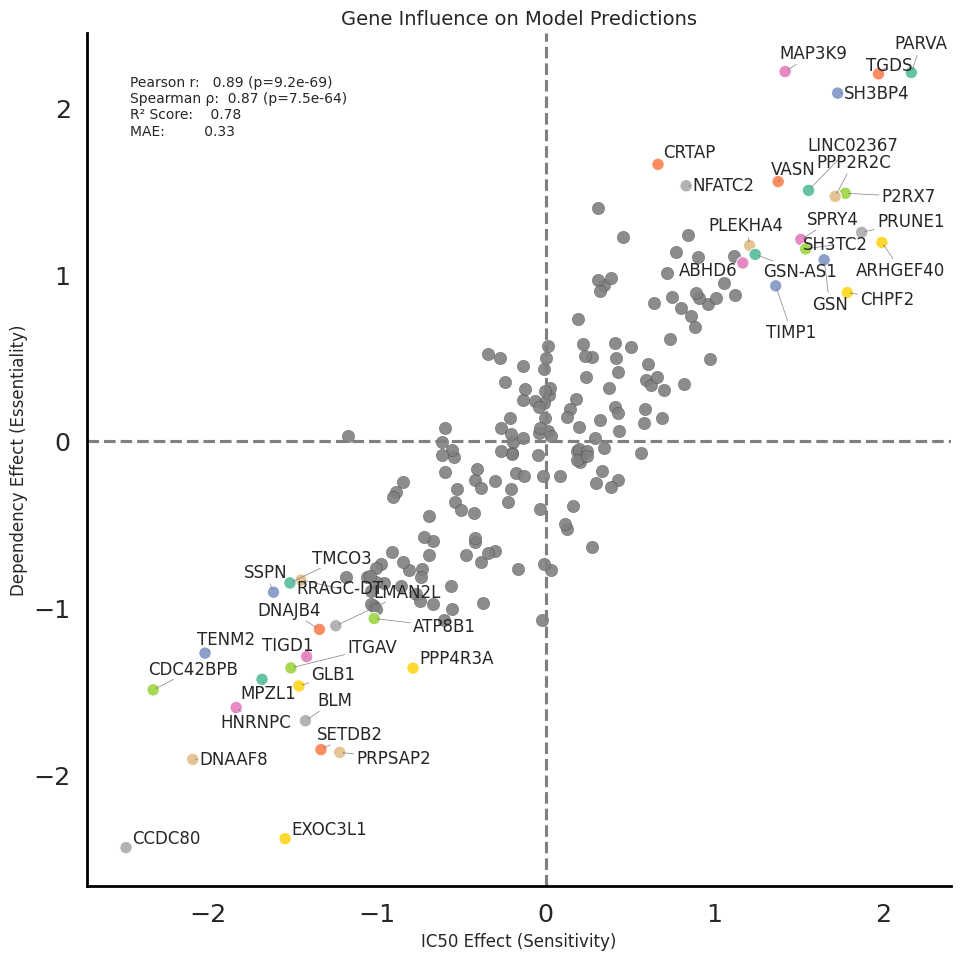

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import r2_score, mean_absolute_error

# === Updated Plotting Function ===
def plot_gene_influence_scatter(influence_df, top_n=20):
    df_scaled = influence_df.copy()
    
    # Z-score scaling
    #for col in df_scaled.columns:
    #   df_scaled[col] = (df_scaled[col] - df_scaled[col].mean()) / df_scaled[col].std()

    # Get top/bottom genes by total influence
    sorted_genes = df_scaled.sort_values("TotalInfluence", ascending=False)
    top_genes = sorted_genes.head(top_n)
    bottom_genes = sorted_genes.tail(top_n)
    key_genes_df = pd.concat([top_genes, bottom_genes])

    # === Scatter plot setup
    fig, ax = plt.subplots(figsize=(10, 10))
    # === Rasterize background points (non-key genes)
    # Mask out key genes
    non_key_genes_df = df_scaled.drop(key_genes_df.index)

    # Plot background genes in grey
    sns.scatterplot(
        data=non_key_genes_df, x="IC50Effect", y="DependencyEffect",
        alpha= 0.9, ax=ax, rasterized=True,
        color='grey', edgecolor='black', linewidth=0.15
    )

    # Highlight top & bottom genes
    # === Top/bottom genes (keep editable/vector)
    sns.scatterplot(
        data=key_genes_df, x="IC50Effect", y="DependencyEffect",
        hue=key_genes_df.index, alpha = 1, palette="Set2", s=80, legend=False, ax=ax,
        rasterized=False  # <== key part!
    )

    # Annotate key genes
    texts = [ax.text(row["IC50Effect"], row["DependencyEffect"], gene, fontsize=12)
             for gene, row in key_genes_df.iterrows()]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

    # Axes styling
    ax.set_title("Gene Influence on Model Predictions", fontsize=14)
    ax.set_xlabel("IC50 Effect (Sensitivity)", fontsize=12)
    ax.set_ylabel("Dependency Effect (Essentiality)", fontsize=12)
    ax.axhline(0, ls='--', color='grey')
    ax.axvline(0, ls='--', color='grey')

    # === Compute Metrics
    x = df_scaled["IC50Effect"].values
    y = df_scaled["DependencyEffect"].values
    pearson_corr, pearson_p = pearsonr(x, y)
    spearman_corr, spearman_p = spearmanr(x, y)
    kendall_corr, kendall_p = kendalltau(x, y)
    r2 = r2_score(x, y)
    mae = mean_absolute_error(x, y)

    # === Add metrics box
    metrics_text = (
        f"Pearson r:   {pearson_corr:.2f} (p={pearson_p:.1e})\n"
        f"Spearman ρ:  {spearman_corr:.2f} (p={spearman_p:.1e})\n"
        #f"Kendall τ:   {kendall_corr:.2f} (p={kendall_p:.1e})\n"
        f"R² Score:    {r2:.2f}\n"
        f"MAE:         {mae:.2f}"
    )
    ax.text(0.05, 0.95, metrics_text,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=1))

    # Despine top and right spines
    sns.despine(top=True, right=True)
        # === Add this block ===
    ax.tick_params(axis='both', which='both', length=8, width=2, direction='out', color='black')
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    plt.tight_layout()
    
    # === Save figure as PDF ===
    plt.savefig("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/Dabrafenib_Gene_influence_scatterplot.pdf", format="pdf", dpi=600, bbox_inches="tight")
    plt.show()

plot_gene_influence_scatter(influence_df, top_n=20)
